In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uraninjo/augmented-alzheimer-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'augmented-alzheimer-mri-dataset' dataset.
Path to dataset files: /kaggle/input/augmented-alzheimer-mri-dataset


Device: cuda

--- Phase 1: Deduplication ---
  Kept 6171 unique slices from /kaggle/input/augmented-alzheimer-mri-dataset/OriginalDataset

  Train: 4319 | Val: 926 | Test: 926


Computing stats: 100%|██████████| 2000/2000 [00:04<00:00, 481.36it/s]


  mean=['0.281', '0.281', '0.281']  std=['0.327', '0.327', '0.327']

Classes: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
Epoch 01/15 | Loss: 1.2739 | AUC: 0.7808 | F1: 0.3612
Epoch 02/15 | Loss: 1.0461 | AUC: 0.8202 | F1: 0.4755
Epoch 03/15 | Loss: 0.8625 | AUC: 0.8393 | F1: 0.5177
Epoch 04/15 | Loss: 0.7399 | AUC: 0.8730 | F1: 0.6589
Epoch 05/15 | Loss: 0.6985 | AUC: 0.8715 | F1: 0.6438
Epoch 06/15 | Loss: 0.6297 | AUC: 0.8931 | F1: 0.7214
Epoch 07/15 | Loss: 0.5751 | AUC: 0.8946 | F1: 0.6561
  Unfroze layer3
Epoch 08/15 | Loss: 0.4934 | AUC: 0.9108 | F1: 0.7410
Epoch 09/15 | Loss: 0.4368 | AUC: 0.9112 | F1: 0.7428
Epoch 10/15 | Loss: 0.4321 | AUC: 0.9279 | F1: 0.7861
Epoch 11/15 | Loss: 0.3786 | AUC: 0.9353 | F1: 0.7798
Epoch 12/15 | Loss: 0.3713 | AUC: 0.9399 | F1: 0.7986
Epoch 13/15 | Loss: 0.3259 | AUC: 0.9426 | F1: 0.8111
Epoch 14/15 | Loss: 0.3061 | AUC: 0.9501 | F1: 0.8187
Epoch 15/15 | Loss: 0.2940 | AUC: 0.9554 | F1: 0.8357

  Best Val F1: 0.8357


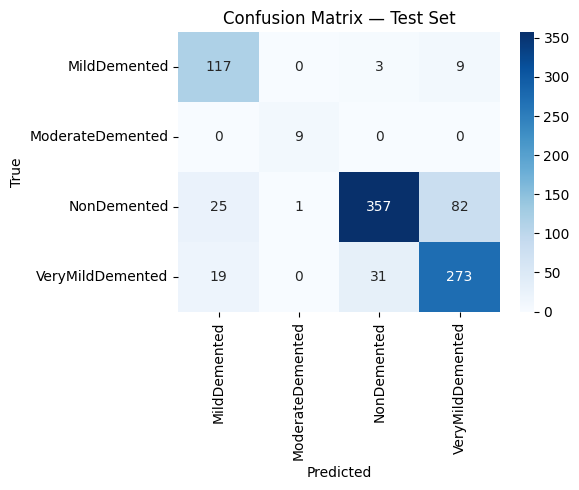

  Saved confusion_matrix.png


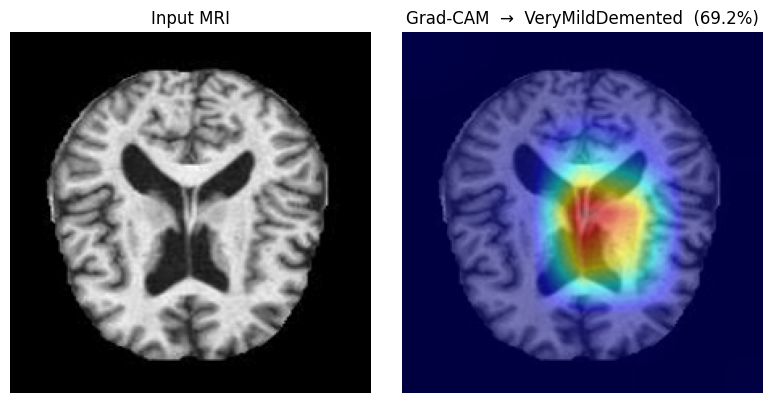

  Saved gradcam.png

--- Sample Inference ---
{'prediction': 'VeryMildDemented', 'confidence': {'MildDemented': 0.0823, 'ModerateDemented': 0.0015, 'NonDemented': 0.1795, 'VeryMildDemented': 0.7367}}

Model saved to maveric_ad_final.pth


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_loss,█▆▅▄▄▃▃▂▂▂▂▂▁▁▁
val_auc,▁▃▃▅▅▆▆▆▆▇▇▇▇██
val_f1,▁▃▃▅▅▆▅▇▇▇▇▇███
epoch,15
train_loss,0.294
val_auc,0.95539
val_f1,0.83575


In [ ]:
# ==============================================================================
# MAVeRiC-AD | Alzheimer's MRI Classification
# ResNet50 · 4-Class · Temperature Calibration · Grad-CAM
# ==============================================================================

import os, copy, random
import imagehash
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
from tqdm import tqdm
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report, roc_auc_score
)

try:
    import wandb
    wandb.init(project="MAVeRiC-AD", config={
        "lr": 1e-4, "epochs": 15, "batch_size": 32, "weight_decay": 1e-4
    })
    USE_WANDB = True
except Exception:
    USE_WANDB = False
    print("W&B not available — logging to console only.")


# ── Reproducibility ──────────────────────────────────────────────────────────
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


# DATASET NORMALIZATION — computed from data, not hardcoded

def compute_dataset_stats(image_paths, sample_size=2000):
    """Compute per-channel mean & std on a random sample of the dataset."""
    sample = random.sample(image_paths, min(sample_size, len(image_paths)))
    to_tensor = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
    pixels = []
    for path in tqdm(sample, desc="Computing stats"):
        try:
            pixels.append(to_tensor(Image.open(path).convert("RGB")))
        except Exception:
            continue
    stack = torch.stack(pixels)                        # (N, 3, 224, 224)
    mean = stack.mean(dim=[0, 2, 3]).tolist()
    std  = stack.std(dim=[0, 2, 3]).tolist()
    print(f"  mean={[f'{v:.3f}' for v in mean]}  std={[f'{v:.3f}' for v in std]}")
    return mean, std

# DEDUPLICATION — perceptual hashing removes near-duplicate slices

def phash_deduplicate(dataset_path):
    """Walk dataset_path, keep one image per unique perceptual hash."""
    print("\n--- Phase 1: Deduplication ---")
    seen, unique = {}, []
    for root, _, files in os.walk(dataset_path):
        for f in files:
            if not f.lower().endswith(("png", "jpg", "jpeg")):
                continue
            path = os.path.join(root, f)
            try:
                h = str(imagehash.phash(Image.open(path)))
                if h not in seen:
                    seen[h] = path
                    unique.append((path, os.path.basename(root)))
            except Exception:
                continue
    print(f"  Kept {len(unique)} unique slices from {dataset_path}")
    return unique

#   DATASET & SPLITS
#   Simple stratified split into train / val / test (70 / 15 / 15)
class MRIDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items          # list of (path, label_int)
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label = self.items[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


def build_dataloaders(dataset_path, batch_size=32):
    raw = phash_deduplicate(dataset_path)
    class_names = sorted({lbl for _, lbl in raw})
    cls_to_idx  = {c: i for i, c in enumerate(class_names)}
    items = [(p, cls_to_idx[lbl]) for p, lbl in raw]

    paths, labels = zip(*items)

    # ── Stratified 70/15/15 split ─────────────────────────────────────────
    tr_p, tmp_p, tr_l, tmp_l = train_test_split(
        paths, labels, test_size=0.30, stratify=labels, random_state=42
    )
    va_p, te_p, va_l, te_l = train_test_split(
        tmp_p, tmp_l, test_size=0.50, stratify=tmp_l, random_state=42
    )
    print(f"\n  Train: {len(tr_p)} | Val: {len(va_p)} | Test: {len(te_p)}")

    # ── Compute normalization from training data only ─────────────────────
    mean, std = compute_dataset_stats(list(tr_p))

    train_tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    train_ds = MRIDataset(list(zip(tr_p, tr_l)), train_tf)
    val_ds   = MRIDataset(list(zip(va_p, va_l)), eval_tf)
    test_ds  = MRIDataset(list(zip(te_p, te_l)), eval_tf)

    # ── Class-balanced loss weights ───────────────────────────────────────
    counts  = Counter(tr_l)
    n_cls   = len(class_names)
    weights = torch.tensor(
        [len(tr_l) / (n_cls * max(counts[i], 1)) for i in range(n_cls)],
        dtype=torch.float32
    ).to(DEVICE)

    loader_kwargs = dict(batch_size=batch_size, num_workers=2, pin_memory=True)
    return (
        DataLoader(train_ds, shuffle=True,  **loader_kwargs),
        DataLoader(val_ds,   shuffle=False, **loader_kwargs),
        DataLoader(test_ds,  shuffle=False, **loader_kwargs),
        class_names, weights, eval_tf
    )


# MODEL — ResNet-50 with progressive layer unfreezing

def build_model(num_classes, unfreeze_layers=("layer4", "fc")):
    """
    Progressive unfreezing: start with only the head trainable.
    Call unfreeze_layer(model, 'layer3') mid-training to open more capacity.
    """
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False                    # freeze everything

    for name, param in model.named_parameters():
        if any(name.startswith(l) for l in unfreeze_layers):
            param.requires_grad = True

    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model.to(DEVICE)


def unfreeze_layer(model, layer_name):
    """Call during training to progressively unfreeze deeper layers."""
    for name, param in model.named_parameters():
        if name.startswith(layer_name):
            param.requires_grad = True
    print(f"  Unfroze {layer_name}")


# TRAINING

def train(model, train_loader, val_loader, class_weights, epochs=15, lr=1e-4):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    # Track Val F1; unfreeze layer3 if plateau persists
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=2, factor=0.5
    )
    scaler = GradScaler("cuda")

    best_f1, best_weights = 0.0, copy.deepcopy(model.state_dict())

    # Unfreeze layer3 at epoch 8 for progressive fine-tuning
    UNFREEZE_EPOCH = 8

    for epoch in range(1, epochs + 1):
        if epoch == UNFREEZE_EPOCH:
            unfreeze_layer(model, "layer3")
            # Rebuild optimizer to include unfrozen params
            optimizer = optim.Adam(
                filter(lambda p: p.requires_grad, model.parameters()),
                lr=lr / 5, weight_decay=1e-4
            )

        # ── Train ────────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with autocast("cuda"):
                loss = criterion(model(images), labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * len(images)

        # ── Validate ─────────────────────────────────────────────────────
        all_preds, all_labels, all_probs = evaluate(model, val_loader)

        val_f1  = f1_score(all_labels, all_preds, average="macro", zero_division=0)
        val_auc = safe_auc(all_labels, all_probs)

        epoch_loss = running_loss / len(train_loader.dataset)
        auc_str = f"{val_auc:.4f}" if val_auc is not None else "N/A"
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Loss: {epoch_loss:.4f} | AUC: {auc_str} | F1: {val_f1:.4f}"
        )

        if USE_WANDB:
            wandb.log({
                "epoch": epoch, "train_loss": epoch_loss,
                "val_f1": val_f1,
                "val_auc": val_auc if val_auc is not None else float("nan")
            })

        scheduler.step(val_f1)
        if val_f1 > best_f1:
            best_f1, best_weights = val_f1, copy.deepcopy(model.state_dict())

    model.load_state_dict(best_weights)
    print(f"\n  Best Val F1: {best_f1:.4f}")
    return model


@torch.no_grad()
def evaluate(model, loader):
    """Returns (predictions, labels, probabilities) as numpy arrays."""
    model.eval()
    preds, labels, probs = [], [], []
    for images, lbls in loader:
        images = images.to(DEVICE)
        with autocast("cuda"):
            logits = model(images)
        # Cast to float32 before numpy — float16 row sums deviate from 1.0
        # and sklearn's roc_auc_score has a strict tolerance that rejects them.
        p = F.softmax(logits.float(), dim=1).cpu().numpy()
        probs.extend(p)
        preds.extend(logits.argmax(dim=1).cpu().numpy())
        labels.extend(lbls.numpy())
    return np.array(preds), np.array(labels), np.array(probs)


def safe_auc(labels, probs):
    """AUC with graceful fallback when a class is absent from the split."""
    try:
        return roc_auc_score(labels, probs, multi_class="ovr", average="macro")
    except ValueError as e:
        print(f"  AUC skipped: {e}")
        return None


# TEMPERATURE SCALING — post-hoc calibration
class CalibratedModel(nn.Module):
    def __init__(self, base_model, temperature=1.5):
        super().__init__()
        self.model = base_model
        self.temperature = nn.Parameter(torch.tensor([temperature]))

    def forward(self, x):
        return self.model(x) / self.temperature


def calibrate(model, val_loader):
    """Learn a single temperature parameter on the validation set."""
    print("\n--- Temperature Calibration ---")
    calibrated = CalibratedModel(model).to(DEVICE)
    nll = nn.CrossEntropyLoss().to(DEVICE)

    # Collect raw logits once
    logits_all, labels_all = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            logits_all.append(calibrated.model(images.to(DEVICE)))
            labels_all.append(labels.to(DEVICE))
    logits_all = torch.cat(logits_all)
    labels_all = torch.cat(labels_all)

    # Only the temperature parameter is optimised
    optimizer = optim.LBFGS([calibrated.temperature], lr=0.01, max_iter=100)

    def lbfgs_closure():
        optimizer.zero_grad()
        loss = nll(logits_all / calibrated.temperature, labels_all)
        loss.backward()
        return loss

    optimizer.step(lbfgs_closure)
    print(f"  Learned temperature: {calibrated.temperature.item():.4f}")
    return calibrated


# EVALUATION — confusion matrix + report on the held-out TEST set
def full_evaluation(model, test_loader, class_names):
    print("\n--- Final Test Evaluation ---")
    preds, labels, probs = evaluate(model, test_loader)

    print(classification_report(labels, preds, target_names=class_names, zero_division=0))

    auc = safe_auc(labels, probs)
    if auc is not None:
        print(f"Macro AUC: {auc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, ax=ax
    )
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("Confusion Matrix — Test Set")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()
    print("  Saved confusion_matrix.png")

#GRAD-CAM — visualise what the model focuses on

def visualize_gradcam(model, image_path, eval_tf, class_names, save_path="gradcam.png"):
    """Overlay Grad-CAM saliency map on an input MRI slice."""
    base = model.model if isinstance(model, CalibratedModel) else model
    cam  = GradCAM(model=base, target_layers=[base.layer4[-1]])

    raw   = Image.open(image_path).convert("RGB").resize((224, 224))
    inp   = eval_tf(raw).unsqueeze(0).to(DEVICE)
    mask  = cam(input_tensor=inp, targets=None)[0]          # highest-scoring class

    overlay = show_cam_on_image(
        np.array(raw, dtype=np.float32) / 255.0, mask, use_rgb=True
    )

    with torch.no_grad():
        logits = model(inp)
    pred_idx  = logits.argmax(1).item()
    pred_name = class_names[pred_idx]
    conf      = F.softmax(logits, dim=1)[0, pred_idx].item()

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(raw); axes[0].set_title("Input MRI"); axes[0].axis("off")
    axes[1].imshow(overlay)
    axes[1].set_title(f"Grad-CAM  →  {pred_name}  ({conf:.1%})")
    axes[1].axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"  Saved {save_path}")


 # INFERENCE API

def predict(model, image_path, eval_tf, class_names):
    """Single-image inference. Returns predicted class + confidence dict."""
    model.eval()
    inp  = eval_tf(Image.open(image_path).convert("RGB")).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = F.softmax(model(inp), dim=1).cpu().numpy()[0]
    scores = {class_names[i]: round(float(probs[i]), 4) for i in range(len(class_names))}
    return {"prediction": class_names[probs.argmax()], "confidence": scores}


# MAIN
if __name__ == "__main__":
    DATA_DIR   = "/kaggle/input/augmented-alzheimer-mri-dataset/OriginalDataset"
    EPOCHS     = 15
    BATCH_SIZE = 32

    # ── Build loaders ────────────────────────────────────────────────────────
    train_loader, val_loader, test_loader, class_names, weights, eval_tf = \
        build_dataloaders(DATA_DIR, batch_size=BATCH_SIZE)

    print(f"\nClasses: {class_names}")

    # ── Train ────────────────────────────────────────────────────────────────
    model = build_model(len(class_names))
    model = train(model, train_loader, val_loader, weights, epochs=EPOCHS)

    # ── Calibrate ────────────────────────────────────────────────────────────
    final_model = calibrate(model, val_loader)

    # ── Final evaluation on held-out test set ────────────────────────────────
    full_evaluation(final_model, test_loader, class_names)

    # ── Grad-CAM on one test image ───────────────────────────────────────────
    sample_path = test_loader.dataset.items[0][0]
    visualize_gradcam(final_model, sample_path, eval_tf, class_names)

    # ── Inference demo ───────────────────────────────────────────────────────
    print("\n--- Sample Inference ---")
    print(predict(final_model, sample_path, eval_tf, class_names))

    # ── Save model ───────────────────────────────────────────────────────────
    torch.save(final_model.state_dict(), "maveric_ad_final.pth")
    print("\nModel saved to maveric_ad_final.pth")

    if USE_WANDB:
        wandb.finish()